# Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/03m2kj587' -- 'Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Hannover,"Faculty II, Hochschule Hannover, University of...",https://openalex.org/W4295854622
1,not assigned,Hochschule Hannover,"University of Applied Sciences, Hannover, Germany",https://openalex.org/W4285111838
2,not assigned,Hochschule Hannover,Hochschule Hannover,https://openalex.org/W4297237915
3,not assigned,Hochschule Hannover,"Christian Wartena, Professor, Hochschule Hanno...",https://openalex.org/W4285248185
4,not assigned,Hochschule Hannover,"Research Group Pharmaceutical Biotechnology, T...",https://openalex.org/W4214548415


In [12]:
MAPPING_DICT = {
    'Fakultät I - Elektro- und Informationstechnik': ['informationstechnik', 'electrical', 'sensor', 'fa(k|c)ult(at|y|ät) i(?!i)(?!v)', 'high voltage'],
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': ['bioprocess', 'mechanical engineering', 'microbiology', 'bioplastics',
                                                            'mechatronics', 'verfahrenstechnik', 'fa(k|c)ult(at|y|ät) ii(?!i)'
                                                           ],
    'Fakultät III - Medien, Information und Design': ['expo plaza', 'design and media', 'fa(k|c)ult(at|y|ät) iii', 'information and communication',
                                                      'design', 'information und kommunikation'
                                                     ],
    'Fakultät IV - Wirtschaft und Informatik': ['computer science', 'fa(k|c)ult(at|y|ät) iv', 'business information'],
    'Fakultät V - Diakonie, Gesundheit und Soziales': ['soziale arbeit', 'social work', 'blumhard(str.|(t)?straße)', 'diakonie', 'nursing', 'health'],
    'Institute for Applied Data Science Hannover (Data|H)': ['data(\|)?h', 'applied data science']
}

In [13]:
with open('./mapping_tables_fak/hsh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [14]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [15]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [16]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät II - Maschinenbau und Bioverfahrenste...,Hochschule Hannover,"Faculty II, Hochschule Hannover, University of...",https://openalex.org/W4295854622
1,None,Hochschule Hannover,"University of Applied Sciences, Hannover, Germany",https://openalex.org/W4285111838
2,None,Hochschule Hannover,Hochschule Hannover,https://openalex.org/W4297237915
3,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Christian Wartena, Professor, Hochschule Hanno...",https://openalex.org/W4285248185
4,None,Hochschule Hannover,"Research Group Pharmaceutical Biotechnology, T...",https://openalex.org/W4214548415
...,...,...,...,...
584,"Fakultät III - Medien, Information und Design",Hochschule Hannover,Hochschule Hannover – University of Applied Sc...,https://openalex.org/W4205625683
585,None,Hochschule Hannover,Hannover University of Applied Sciences and Arts,https://openalex.org/W7135738805
586,None,Hochschule Hannover,Department of Clinical Research and Epidemiolo...,https://openalex.org/W4256530494
587,None,Hochschule Hannover,"University of Applied Sciences and Arts, Hanov...",https://openalex.org/W3095801723


In [23]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Applied Sciences, Hannover, Germany',
       'Hochschule Hannover',
       'Research Group Pharmaceutical Biotechnology, TH Köln - University of Applied Sciences; Institute of Technical Chemistry, Leibniz University Hannover',
       'University of Applied Administrative Sciences, Wielandstr. 8, 30169, Hannover, Germany',
       'Interactive Reality Experiences, Hannover University of Applied Sciences and Arts, Germany',
       'University of Applied Sciences and Arts Hannover  Germany',
       'University of Applied Sciences and Arts Hannover, Germany',
       'University of Applied Sciences and Arts Hannover, 1 30459 Hannover, Germany;',
       'Hochschule Hannover, Hannover, Deutschland',
       'Hannover University of Applied Sciences and Arts, Hanover, Germany',
       'Hannover University of Applied Sciences and Arts,Hanover,Germany',
       'Hannover University of Applied Sciences and Arts',
       'Prof. Dr.-Ing. Karl-Heinz Niemann, Hochschule Hannover, Ha

In [24]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät I - Elektro- und Informationstechnik,39
1,Fakultät II - Maschinenbau und Bioverfahrenste...,106
2,"Fakultät III - Medien, Information und Design",93
3,Fakultät IV - Wirtschaft und Informatik,48
4,"Fakultät V - Diakonie, Gesundheit und Soziales",45
5,Institute for Applied Data Science Hannover (D...,13
6,NaN,245


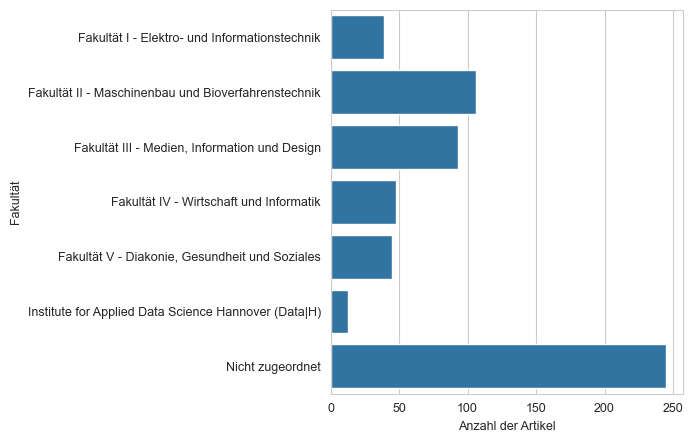

In [25]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [26]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5840407470288624

In [27]:
MAPPING_DICT_DEPT = {
    'Fakultät I - Elektro- und Informationstechnik': {
        #'Fachgebiet Elektrische Antriebe und Automatisierungstechnik': [],
        #'Fachgebiet Elektrische Anlagen': [],
        #'Fachgebiet Elektrische Messtechnik': [],
        #'Fachgebiet Grundlagen der Elektrotechnik': [],
        #'Fachgebiet Hochfrequenz- und Mikrowellentechnik': [],
        #'Fachgebiet Hochspannungstechnik': [],
        #'Fachgebiet Industrieelektronik und Digitaltechnik': [],
        #'Fachgebiet Ingenieurinformatik': [],
        #'Fachgebiet Kommunikationstechnik': [],
        #'Fachgebiet Physik': [],
        #'Fachgebiet Prozessinformatik und Automatisierungstechnik': [],
        #'Fachgebiet Regelungstechnik': [],
        #'Fachgebiet Technische Redaktion': [],
        #'Fachgebiet Technologie': [],
    },
    'Fakultät II - Maschinenbau und Bioverfahrenstechnik': {
        #'Abteilung Maschinenbau': [],
        #'Fachgebiet Automatisierungstechnik': [],
        #'Fachgebiet Förder- und Handhabungstechnik, Logistik und Materialflusstechnik (FHLM)': [],
        #'Fachgebiet Umformtechnik': [],
        'Fachgebiet Verfahrens-, Energie- und Umwelttechnik': ['verfahrenstechnik'],
        #'Fachgebiet Werkstoffkunde': [],
        'Institut für Biokunststoffe und Bioverbundwerkstoffe (ifBB)': ['bioplastics'],
        #'Labor Digitale Fabrik': [],
        #'Mechanische Verfahrenstechnik Labor (M-H-35-02)': [],
    },
    'Fakultät III - Medien, Information und Design': {
        #'Abteilung Design und Medien': [],
        #'Abteilung Information und Kommunikation': [],
    }
}

In [28]:
with open('./mapping_tables_dept/hsh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [29]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [30]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät III - Medien, Information und Design')

In [31]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Christian Wartena, Professor, Hochschule Hannover, Fachbereich Informationsmanagement Expo Plaza 12, 30539 Hannover, Deutschland, DE',
       'Department of Information and Communication, Faculty for Media, Information and Design, University of Applied Sciences and Arts, Hannover, Germany',
       'Faculty III, Hochschule Hannover University of Applied Sciences & Arts, Hannover, Lower Saxony, Germany',
       'UNIRED Research Group, Faculty III, Hochschule Hannover University of Applied Sciences & Arts, Lower Saxony, 30159, Hannover, Germany',
       'Hochschule Hannover Fak. III, Abt. IK Expo Plaza 12 30539 Hannover Deutschland',
       'Hochschule Hannover Fak. III, Abt. IK Expo Plaza 12 Hannover Deutschland',
       'University of Applied Sciences and Arts Hannover, Faculty III – Media, Information and Design, Hannover, Germany',
       'University of Applied Sciences and Arts Hanover, Expo Plaza 12, 30559 Hannover, Germany',
       'Department of Biometry, Epidemiology and 

In [32]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,NaN,93


In [33]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät III - Medien, Information und Design']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
3,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Christian Wartena, Professor, Hochschule Hanno...",https://openalex.org/W4285248185,None
9,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Department of Information and Communication, F...",https://openalex.org/W4220864834,None
24,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Faculty III, Hochschule Hannover University of...",https://openalex.org/W4296667405,None
25,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"UNIRED Research Group, Faculty III, Hochschule...",https://openalex.org/W4296667405,None
29,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Hochschule Hannover Fak. III, Abt. IK Expo Pla...",https://openalex.org/W4229371356,None
...,...,...,...,...,...
570,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Hochschule Hannover, University of Applied Sci...",https://openalex.org/W4393392723,None
573,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Department of Information and Communication, F...",https://openalex.org/W4413986162,None
574,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Department of Information and Communication, F...",https://openalex.org/W4414421679,None
582,"Fakultät III - Medien, Information und Design",Hochschule Hannover,"Fakultät III, Abteilung Information und Kommun...",https://openalex.org/W3213118210,None


In [34]:
MAPPING_DICT_INST = {}

In [36]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Hochschule Hannover'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/hsh.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)